In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import drive
drive.mount('/content/drive/')
import os
os.chdir('/content/drive/MyDrive/Data science studies/Aprendizado-de-maquina-UFSC/final-project/data')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
<built-in function chroot>


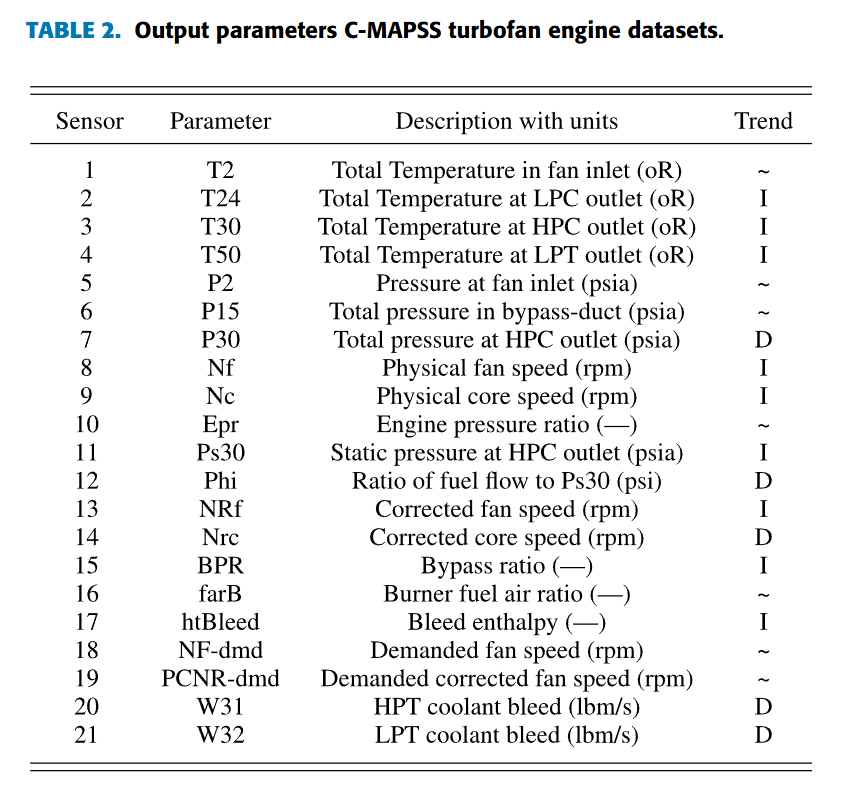

In [12]:
# Caminhos dos arquivos
train_path = "./6.turbofan rul/train_FD001.txt"
test_path = "./6.turbofan rul/test_FD001.txt"
rul_path = "./6.turbofan rul/RUL_FD001.txt"

# Nomes das colunas (de acordo com a documentação original do C-MAPSS)
column_names = ['engine_id', 'cycle'] + \
               [f'op_setting_{i}' for i in range(1, 4)] + \
               [f'sensor_measurement_{i}' for i in range(1, 22)]

# Importando os arquivos (espaço em branco como delimitador)
df_train = pd.read_csv(train_path, sep='\s+', header=None, names=column_names)
df_test = pd.read_csv(test_path, sep='\s+', header=None, names=column_names)
df_rul = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

In [13]:
df_train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [17]:
df_train.isnull().sum()

,0
engine_id,0
cycle,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_measurement_1,0
sensor_measurement_2,0
sensor_measurement_3,0
sensor_measurement_4,0
sensor_measurement_5,0


In [18]:
def calculate_rul(df_train):
    """
    Adiciona uma coluna 'RUL' ao df_train com base na diferença entre o ciclo máximo e o ciclo atual para cada motor.
    """
    max_cycles = df_train.groupby("engine_id")["cycle"].transform("max")
    df_train["RUL"] = max_cycles - df_train["cycle"]
    return df_train


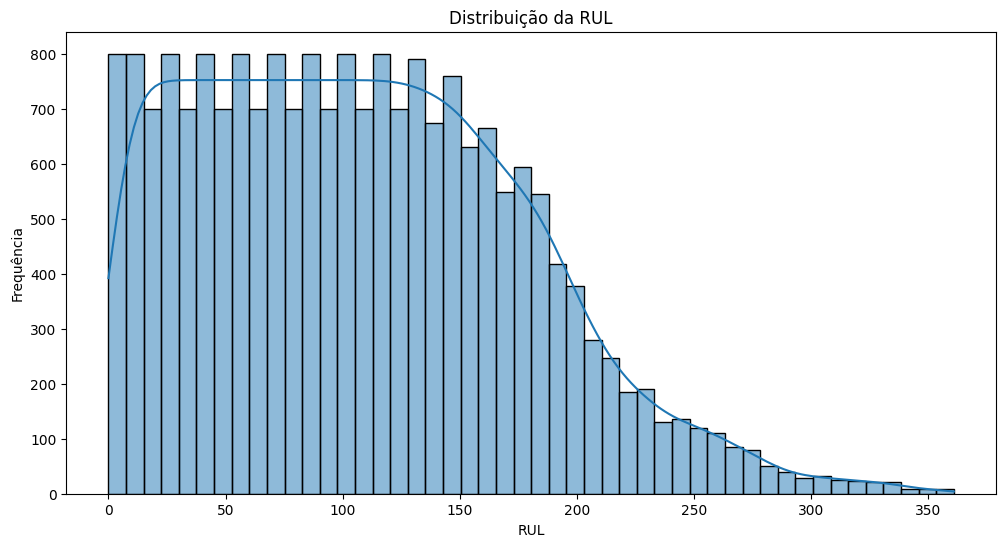

In [25]:
calculate_rul(df_train)

plt.figure(figsize=(12, 6))
sns.histplot(df_train["RUL"], bins="auto", kde=True)
plt.title("Distribuição da RUL")
plt.xlabel("RUL")
plt.ylabel("Frequência")
plt.show()